# Sign Language ABC: From Scratch v4 🤟

**Goal:** Get over 70% with a CNN trained from scratch (no transfer learning).

**What was wrong in v3:**
- 256×256 images are ImageNet-scale — way too large for 981 training images
- SGD needs large datasets to show its advantage — Adam is better for tiny data
- Augmentation was applied on batches (unreliable) instead of per-image

**Fixes:**
- **Resize to 64×64** — 16× less data for the model to process, hand shapes still visible
- **Adam optimizer** — converges faster and more reliably on small datasets
- **Per-image augmentation** — applied correctly before batching
- **4 MaxPool layers** — 64×64 → 32 → 16 → 8 → 4 (proper progressive downsampling)
- Moderate dropout + L2 regularisation

---
## 1.&nbsp; Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization, Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

from sklearn.metrics import classification_report, confusion_matrix
from typing import Dict
from tensorflow.data import Dataset

---
## 2.&nbsp; Load and Resize Data

We load the preprocessed 256×256 data, then **resize to 64×64**. This drastically reduces the feature space the model needs to learn from.

In [2]:
PROCESSED_DIR: str = os.path.expanduser('~/Downloads/processed')
IMG_SIZE: int = 96  # Was 64 — more detail to distinguish A from C  

def load_datasets(
    processed_dir: str,
    batch_size: int = 32
) -> Dict[str, Dataset]:
    splits = [s for s in os.listdir(processed_dir)
              if os.path.isdir(os.path.join(processed_dir, s))]
    datasets = {}
    for split in splits:
        ds = tf.data.Dataset.load(os.path.join(processed_dir, split))
        ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
        datasets[split] = ds
        print(f'{split:5s}: loaded')
    return datasets

BATCH_SIZE: int = 32
datasets = load_datasets(PROCESSED_DIR, BATCH_SIZE)

for split_name, ds in datasets.items():
    count = sum(labels.shape[0] for _, labels in ds)
    print(f'{split_name:5s}: {count} images')

test : loaded
train: loaded
val  : loaded
test : 199 images
train: 981 images
val  : 199 images


In [3]:
NUM_CLASSES: int = 3
class_names: list[str] = ['A', 'B', 'C']

# Resize and normalise
def resize_and_normalise(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    images = tf.image.resize(images, [IMG_SIZE, IMG_SIZE])
    return images, labels

# Per-image augmentation (applied BEFORE batching via unbatch/map/rebatch)
def augment_single(image, label):
    image = tf.image.random_brightness(image, max_delta=0.25)
    image = tf.image.random_contrast(image, lower=0.75, upper=1.25)
    image = tf.image.random_saturation(image, lower=0.75, upper=1.25)
    image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 20, IMG_SIZE + 20)
    image = tf.image.random_crop(image, size=[IMG_SIZE, IMG_SIZE, 3])
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# Prepare datasets
train_ds = (datasets['train']
    .map(resize_and_normalise)
    .unbatch()
    .map(augment_single)  # Per-image augmentation
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = datasets['val'].map(resize_and_normalise)
test_ds = datasets['test'].map(resize_and_normalise)

# Verify
for images, labels in train_ds.take(1):
    print(f'Training batch shape: {images.shape}')
    print(f'Pixel range: {images.numpy().min():.2f} to {images.numpy().max():.2f}')

Training batch shape: (32, 96, 96, 3)
Pixel range: 0.00 to 1.00


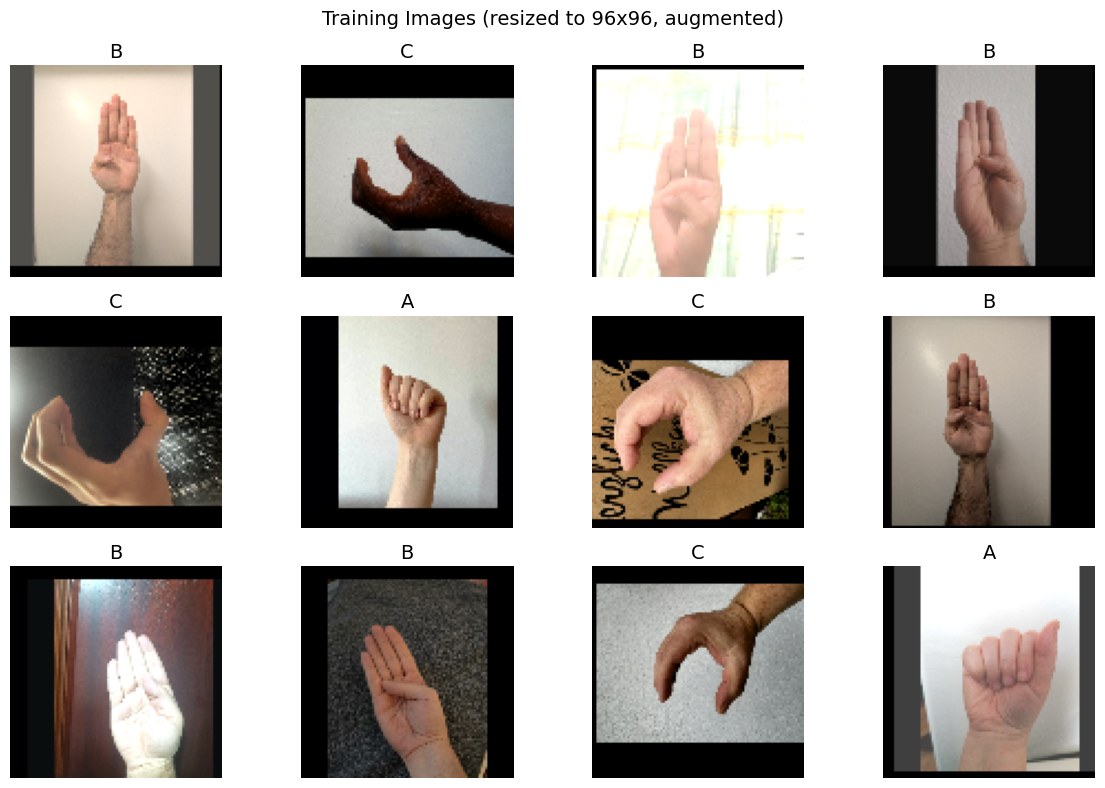

In [4]:
# Preview resized images
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(12, images.shape[0])):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]], fontsize=14)
        plt.axis('off')
plt.suptitle(f'Training Images (resized to {IMG_SIZE}x{IMG_SIZE}, augmented)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3.&nbsp; Build the Model

Simpler architecture matched to 64×64 input:

```
64×64×3 input
Block 1: Conv(32) → BN → ReLU → MaxPool → 32×32  → Dropout(0.25)
Block 2: Conv(64) → BN → ReLU → MaxPool → 16×16  → Dropout(0.25)
Block 3: Conv(128) → BN → ReLU → MaxPool → 8×8   → Dropout(0.3)
Block 4: Conv(128) → BN → ReLU → MaxPool → 4×4   → Dropout(0.3)
GlobalAveragePooling → 128 values
Dense(64) → BN → ReLU → Dropout(0.5)
Dense(3, softmax)
```

Single Conv per block (not double) — keeps parameters low for ~1000 images.

In [5]:
WEIGHT_DECAY: float = 1e-4

model: Sequential = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1: 32 filters
    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(WEIGHT_DECAY)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2: 64 filters
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(WEIGHT_DECAY)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3: 128 filters
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(WEIGHT_DECAY)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Block 4: 128 filters
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(WEIGHT_DECAY)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Classifier
    GlobalAveragePooling2D(),  # 4x4x128 -> 128 values
    Dense(64, kernel_regularizer=l2(WEIGHT_DECAY)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.6),

    Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

print(f'\nParameters per training image: {model.count_params() / 981:.0f}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 250,947 (980.26 KB)

 Trainable params: 250,115 (977.01 KB)

 Non-trainable params: 832 (3.25 KB)


Parameters per training image: 256


---
## 4.&nbsp; Compile with Adam

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

---
## 5.&nbsp; Train

In [8]:
from sklearn.utils.class_weight import compute_class_weight

all_train_labels = []
for _, labels in datasets['train']:
    all_train_labels.extend(labels.numpy())
all_train_labels = np.array(all_train_labels)

weights = compute_class_weight('balanced', classes=np.unique(all_train_labels), y=all_train_labels)
class_weight_dict = dict(enumerate(weights))

print(f'Training label distribution: {np.bincount(all_train_labels)}')
print(f'Class weights: {class_weight_dict}')

Training label distribution: [333 340 308]
Class weights: {0: 0.9819819819819819, 1: 0.961764705882353, 2: 1.0616883116883118}


In [9]:
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_sign_v5.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

start = time.time()

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # <-- NEW: balances the loss per class
    verbose=1
)

train_time = time.time() - start
print(f'\nTraining time: {train_time:.0f}s ({train_time/60:.1f} min)')

Epoch 1/80
     31/Unknown 73s 2s/step - accuracy: 0.3047 - loss: 1.5989

/opt/anaconda3/envs/datascience/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.36181, saving model to best_sign_v5.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.3150 - loss: 1.5787 - val_accuracy: 0.3618 - val_loss: 1.1420 - learning_rate: 0.0010
Epoch 2/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3487 - loss: 1.5135
Epoch 2: val_accuracy did not improve from 0.36181
31/31 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.3445 - loss: 1.4982 - val_accuracy: 0.3317 - val_loss: 1.1602 - learning_rate: 0.0010
Epoch 3/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 872ms/step - accuracy: 0.3189 - loss: 1.4791
Epoch 3: val_accuracy did not improve from 0.36181
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 917ms/step - accuracy: 0.3394 - loss: 1.4279 - val_accuracy: 0.3317 - val_loss: 1.2337 - learning_rate: 0.0010
Epoch 4/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3380 - loss: 1.3692
Epoch 4: val_accuracy improved from 0.36181 to 0.37688, saving model to best_sign_v5.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accur

### 5.1. Load Best Model

In [10]:
model = load_model('best_sign_v5.keras')
print('Loaded best model weights')

Loaded best model weights


---
## 6.&nbsp; Training Curves

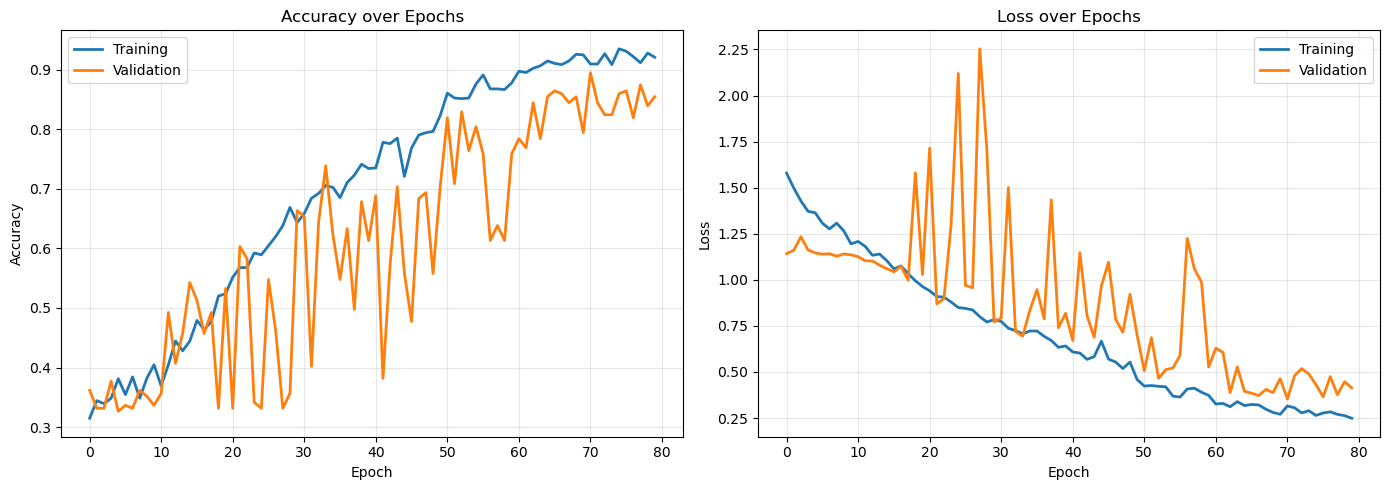

Best epoch:               71
Best validation accuracy: 0.8945
Train acc at best epoch:  0.9093
Train/val gap:            0.0148


In [11]:
h = history.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h['accuracy'], label='Training', linewidth=2)
axes[0].plot(h['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(h['loss'], label='Training', linewidth=2)
axes[1].plot(h['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = np.argmax(h['val_accuracy'])
print(f'Best epoch:               {best_epoch + 1}')
print(f'Best validation accuracy: {max(h["val_accuracy"]):.4f}')
print(f'Train acc at best epoch:  {h["accuracy"][best_epoch]:.4f}')
print(f'Train/val gap:            {h["accuracy"][best_epoch] - h["val_accuracy"][best_epoch]:.4f}')

---
## 7.&nbsp; Evaluate on Test Set

In [12]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Test Accuracy:  {test_acc:.4f}')
print(f'Test Loss:      {test_loss:.4f}')
print(f'Parameters:     {model.count_params():,}')
print(f'Training Time:  {train_time/60:.1f} min')

Test Accuracy:  0.8141
Test Loss:      0.6422
Parameters:     250,947
Training Time:  27.4 min


In [13]:
y_true_list = []
y_pred_list = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(labels.numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           A       0.76      0.79      0.77        43
           B       0.73      0.97      0.83        64
           C       0.96      0.72      0.82        92

    accuracy                           0.81       199
   macro avg       0.81      0.83      0.81       199
weighted avg       0.84      0.81      0.81       199



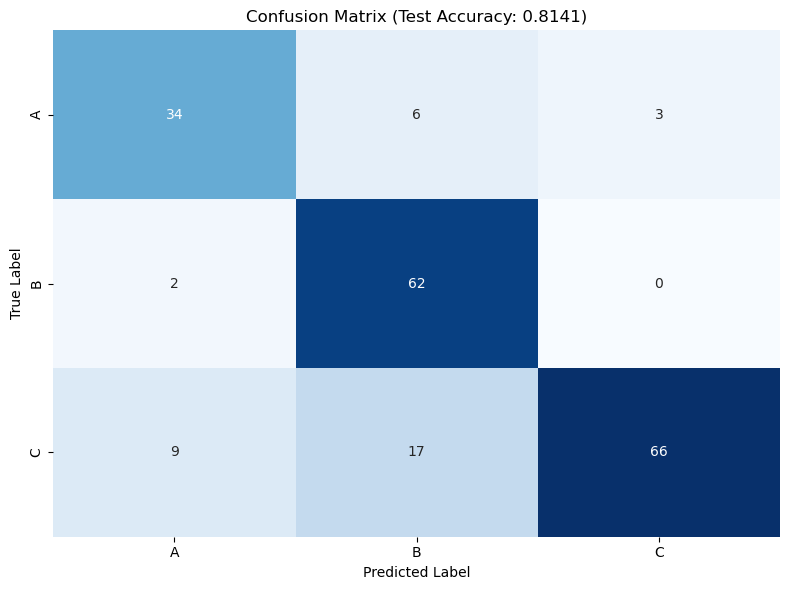

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Test Accuracy: {test_acc:.4f})')
plt.tight_layout()
plt.show()

---
## 8.&nbsp; Misclassified Images

Misclassified: 37 out of 199


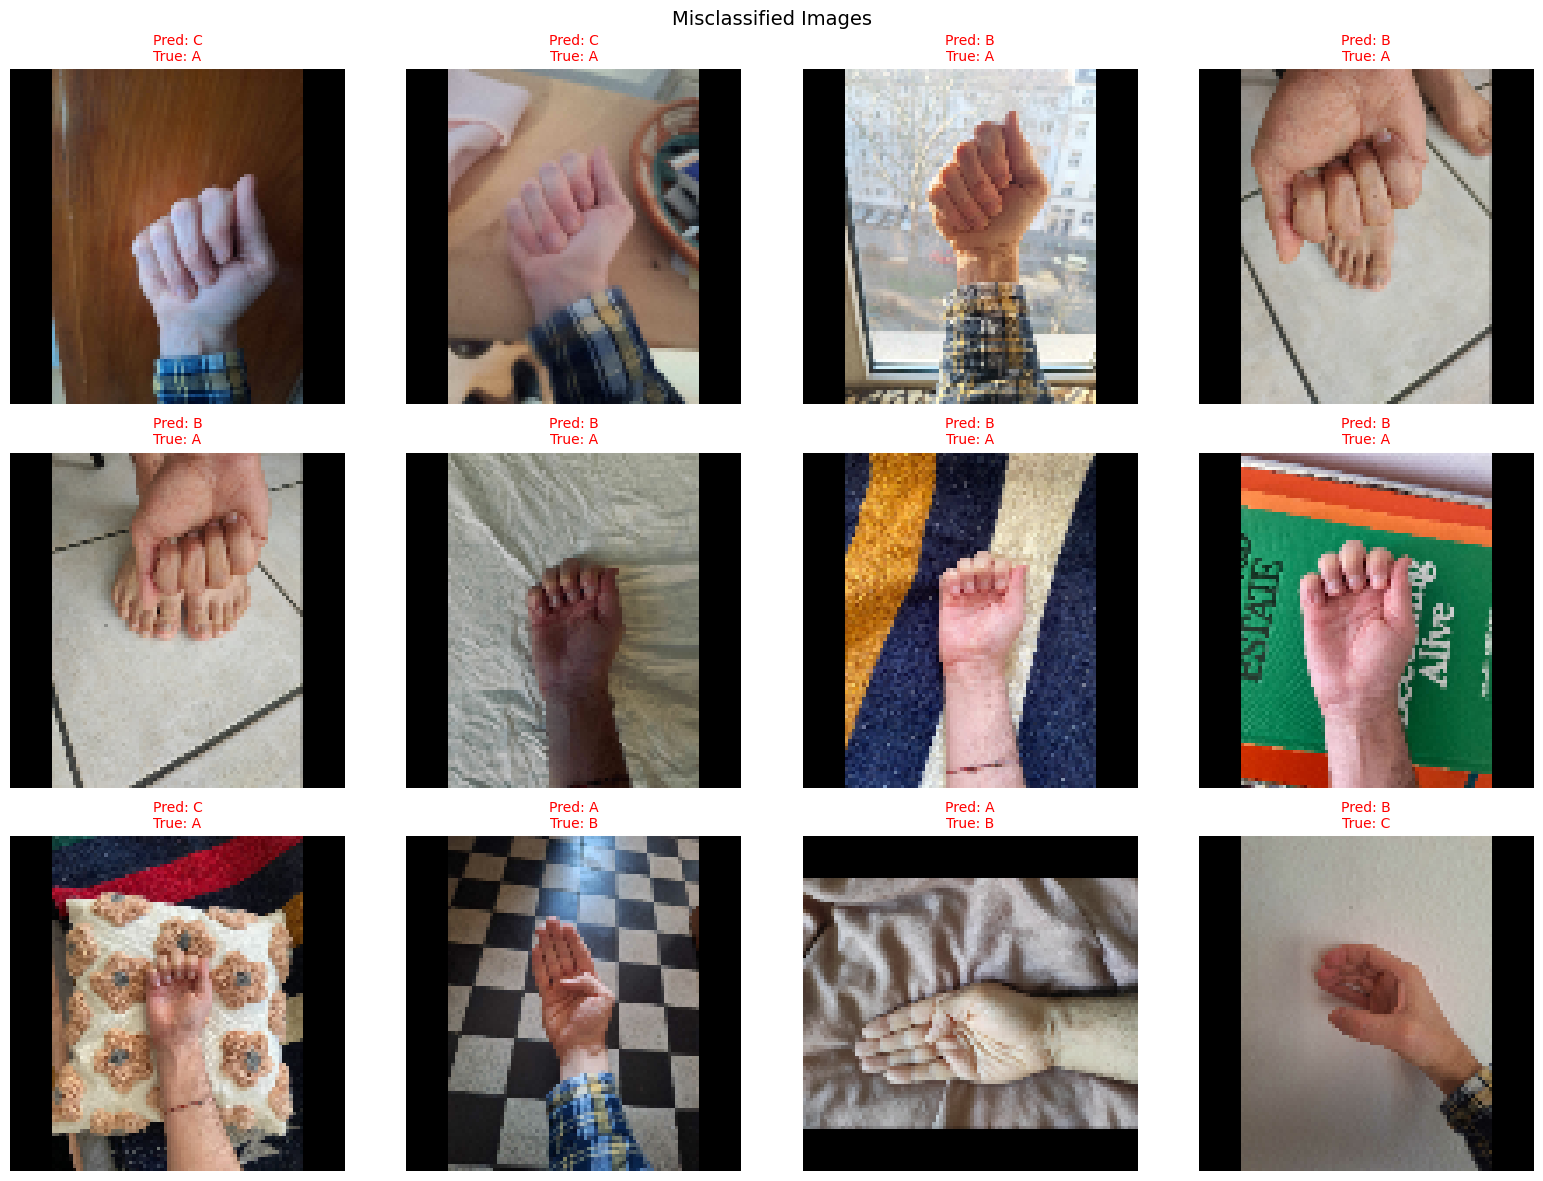

In [15]:
all_test_images = []
for images, labels in test_ds:
    all_test_images.extend(images.numpy())
all_test_images = np.array(all_test_images)

wrong_idx = np.where(y_pred != y_true)[0]
print(f'Misclassified: {len(wrong_idx)} out of {len(y_true)}')

if len(wrong_idx) > 0:
    n_show = min(12, len(wrong_idx))
    cols = min(4, n_show)
    rows = (n_show + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i in range(n_show):
        idx = wrong_idx[i]
        plt.subplot(rows, cols, i + 1)
        plt.imshow(all_test_images[idx])
        plt.title(
            f'Pred: {class_names[y_pred[idx]]}\nTrue: {class_names[y_true[idx]]}',
            color='red', fontsize=10
        )
        plt.axis('off')
    plt.suptitle('Misclassified Images', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No misclassifications!')

---
## 9.&nbsp; The Full Journey

| Model | Approach | Best Val Acc | Test Acc | Issue |
|---|---|---|---|---|
| v2 | 3-block VGG, 256×256, low dropout | ~60% | - | Massive overfitting (39% gap) |
| v3 | 3-block VGG + GAP, 256×256, high dropout | ~58% | - | Fixed overfit but too weak |
| Transfer | MobileNetV2, 256×256 | 98.5% | 97.5% | Pretrained features → easy win |
| **v4** | **4-block, 64×64, Adam, per-image aug** | **??.?%** | **??.?%** | **From scratch, right-sized** |

Update with your result!

---
## 10.&nbsp; Reflect 📝

1. Did resizing to 64×64 help? Compare training speed and accuracy to v3 (256×256).
2. Did Adam converge faster than SGD did in v3?
3. Is the train/val gap reasonable? (5–15% is healthy for small datasets)
4. How does this compare to the transfer learning model? What does the gap tell you about the value of pretrained features?
5. Could you reach 80%+ from scratch? What would you try next?

*Write your reflections here:*

- ...
- ...
- ...